In [ ]:
!pip install --quiet holidays

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Validações, eliminar primeira coluna que não tem informações
path = '../data/validaciones/'
filenames = [
    'val_abril.xlsx', 'val_mayo.xlsx', 'val_junio.xlsx', 'val_julio.xlsx',
    'val_agosto.xlsx', 'val_septiembre.xlsx', 'val_octubre.xlsx', 'val_noviembre.xlsx',
    'val_diciembre.xlsx', 'val_enero_2026.xlsx', 'val_febrero_2026.xlsx', 'val_marzo_2026.xlsx'
]

dfs = [pd.read_excel(f'{path}{f}', header=6) for f in filenames]
# abril, maio, junho, julho, agosto, setembro, outubro, novembro, dezembro, janeiro, fevereiro
df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12 = dfs

**DATA CLEANING**

In [11]:
print(df10.shape, df11.shape) # shape no formato wide
print(df11.shape[0]*30) # Número de linhas no formato long

(78522, 38) (78522, 38)
2355660


Vamos olhar as validações (entradas ao sistema) de outubro de 2025 e fevereiro de 2026:

In [20]:
df7.head(3)

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-10-01 00:00:00,2025-10-02 00:00:00,2025-10-03 00:00:00,2025-10-04 00:00:00,...,2025-10-23 00:00:00,2025-10-24 00:00:00,2025-10-25 00:00:00,2025-10-26 00:00:00,2025-10-27 00:00:00,2025-10-28 00:00:00,2025-10-29 00:00:00,2025-10-30 00:00:00,2025-10-31 00:00:00,Total general
0,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(61413) C004|21 Ángeles A - 2,09:00:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(71386) BD-019A|K7 - CL73 S/N A,14:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,NaN,Dual,(10006) M84-C84,(11474) MC84_V3,(71386) BD-019A|K7 - CL73 S/N A,16:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [19]:
df11.head(3)

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2026-02-01 00:00:00,2026-02-02 00:00:00,2026-02-03 00:00:00,2026-02-04 00:00:00,...,2026-02-23 00:00:00,2026-02-24 00:00:00,2026-02-25 00:00:00,2026-02-26 00:00:00,2026-02-27 00:00:00,2026-02-28 00:00:00,2026-03-01 00:00:00,2026-03-02 00:00:00,2026-03-03 00:00:00,Total general
0,NaN,Dual,(10006) M84-C84,(12387) MC84_V5,(0) (Unknown),07:00:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,7
1,NaN,Dual,(10006) M84-C84,(12387) MC84_V5,(0) (Unknown),07:30:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,1
2,NaN,Dual,(10006) M84-C84,(12387) MC84_V5,(0) (Unknown),09:00:00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,8


In [16]:
for df in dfs:
    print(df['Fase'].unique())

['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 2' 'Fase 1' 'Fase 3' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']
['Dual' 'Fase 3' 'Fase 2' 'Fase 1' nan 'Total general']


As tabelas das validações dos meses com menos de 31 dias contem colunas correspondentes aos primeiros dias do mês seguinte que precisam ser excluidas, além da primeira e última colunas. Além disso, parece que o formato (número de colunas, nombre das colunas, etc) dessas duas tabelas, e por extensão o de todas as tabelas fornecidas por TM é uniforme. O formato das tabelas é 'wide' e precisamos do formato 'long'.

Já é evidente que tem registro de linhas da Fase 'Dual' que corresponden a ônibus que passam também por faixas não exclusivas e têm paradas na rua. Só interessam as linhas que passam pelas faixas exclusivas de TM e param apenas nas estações. Também há valores 'nan' e 'Total general' na coluna Fase, o que deve estar errado.

In [21]:
df11[df11.Fase == 'Total general']

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2026-02-01 00:00:00,2026-02-02 00:00:00,2026-02-03 00:00:00,2026-02-04 00:00:00,...,2026-02-23 00:00:00,2026-02-24 00:00:00,2026-02-25 00:00:00,2026-02-26 00:00:00,2026-02-27 00:00:00,2026-02-28 00:00:00,2026-03-01 00:00:00,2026-03-02 00:00:00,2026-03-03 00:00:00,Total general
78521,NaN,Total general,Total general,Total general,Total general,Total general,575495.0,1909793.0,1921635.0,1942684.0,...,1847698.0,1902155.0,1910652.0,1895121.0,1868874.0,1256272.0,0.0,0.0,0.0,45070566


In [23]:
df8[df11['Fase'].isnull()]

,Unnamed: 0,Fase,Línea,Estación,Acceso de Estación,Intervalo,2025-11-01 00:00:00,2025-11-02 00:00:00,2025-11-03 00:00:00,2025-11-04 00:00:00,...,2025-11-23 00:00:00,2025-11-24 00:00:00,2025-11-25 00:00:00,2025-11-26 00:00:00,2025-11-27 00:00:00,2025-11-28 00:00:00,2025-11-29 00:00:00,2025-11-30 00:00:00,2025-12-01 00:00:00,Total general
53725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
53729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


Tem mais de 25 mil linhas totalmente nulas em novembro (caso similar para outubro). O valor Fase = 'Total general' corresponde a uma linha de sumarização. Vamos eliminar as linhas com Fase 'Dual', 'nan', e 'Total general' e conservar as outras:

In [27]:
df1.shape

(78522, 38)

In [37]:
dfs_clean = []
for i, df in enumerate(dfs, 1):
    df = df[df['Fase'].isin(['Fase 1', 'Fase 2', 'Fase 3'])]
    globals()[f'df{i}_clean'] = df
    dfs_clean.append(df)

Agora vamos mudar os dataframes ao formato 'long':

In [43]:
# Months with 30 days: april, june, september, november
month30 = [1,3,6,8]

# Months with 31 days: may, july, august, october, december, january, march
month31 = [2,4,5,7,9,10,12]

dfs_long = []
for i, df in enumerate(dfs_clean, 1):

    if i in month30:
        cols_to_melt = df.columns[6:-2]
    elif i in month31:
        cols_to_melt = df.columns[6:-1]
    else: # for february
        cols_to_melt = df.columns[6:-4]

    df_long = df.melt(id_vars = ['Fase', 'Línea', 'Estación', 'Acceso de Estación', 'Intervalo'],
                      value_vars = cols_to_melt, var_name = 'Fecha', value_name = 'Validaciones')

    globals()[f'df{i}_long'] = df_long
    dfs_long.append(df_long)

Vamos concatenar os dataframes:

In [60]:
# Juntar todos los 12 dataframes en orden
df_val = pd.concat(dfs_long, axis=0, ignore_index=True)
print(df_val.shape)

(11017584, 7)


In [62]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017584 entries, 0 to 11017583
Data columns (total 7 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Fase                object 
 1   Línea               object 
 2   Estación            object 
 3   Acceso de Estación  object 
 4   Intervalo           object 
 5   Fecha               object 
 6   Validaciones        float64
dtypes: float64(1), object(6)
memory usage: 588.4+ MB


As colunas Intervalo e Data deveriam ser de tipo timestamp ou datetime. E é mais útil que as duas estejam na mesma coluna:

In [63]:
# Mudar tipo de dado da data e hora de object a datetime
# dt.normalize() é para garantir que todas as horas estão na meia noite 00:00:00
df_val['Fecha'] = df_val['Fecha'].astype(str).str.split(' ').str[0].str.strip()
delta_horas = df_val['Intervalo'].astype(str).str.strip()
df_val['Fecha'] = pd.to_datetime(df_val['Fecha'] + ' ' + delta_horas, format = '%Y-%m-%d %H:%M:%S')
df_val.drop('Intervalo', axis=1, inplace=True)

df_val.head()

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
0,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-04-01 04:00:00,0.0
1,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-04-01 04:15:00,0.0
2,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-04-01 04:30:00,2.0
3,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-04-01 04:45:00,6.0
4,Fase 3,(11) Zona K Calle 26,(06001) Modelia,(01) Acceso Peatonal Oriental,2025-04-01 05:00:00,27.0


In [64]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017584 entries, 0 to 11017583
Data columns (total 6 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Fase                object        
 1   Línea               object        
 2   Estación            object        
 3   Acceso de Estación  object        
 4   Fecha               datetime64[ns]
 5   Validaciones        float64       
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 504.3+ MB


In [65]:
# Verificar linhas duplicadas
print('Linhas repetidas:', df_val.duplicated().sum())

Linhas repetidas: 0


In [66]:
# Verificar outros nulos
df_val.isna().sum()

Fase                  0
Línea                 0
Estación              0
Acceso de Estación    0
Fecha                 0
Validaciones          0
dtype: int64

**EDA**

In [67]:
df_val['Validaciones'].describe()

count    1.101758e+07
mean     3.524027e+01
std      8.156113e+01
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e+00
75%      3.600000e+01
max      1.931000e+03
Name: Validaciones, dtype: float64

O valor máximo de 1931 validações chama a atenção:

In [69]:
df_val[df_val['Validaciones'] == 1931]

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
3935791,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-08-06 06:00:00,1931.0


In [70]:
df_val.sort_values(by='Validaciones', ascending=False).head(10)

,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
3935791,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-08-06 06:00:00,1931.0
296420,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-04-10 06:00:00,1854.0
1372243,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-05-14 06:00:00,1822.0
6811336,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:30:00,1818.0
2656595,Fase 1,(34) Zona H Caracas Sur,(08000) Portal Tunal,(KD) DESALIMENTACIÓN - SAN JOAQUÍN /JJ RONDÓN ...,2025-06-25 06:30:00,1817.0
3935794,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-08-06 06:45:00,1816.0
10203072,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2026-03-04 06:30:00,1795.0
6871598,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-12 06:00:00,1794.0
1653051,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-05-23 05:45:00,1789.0
6811337,Fase 2,(31) Zona F Av. Américas,(05000) Portal Américas,(23) Acceso Peatonal,2025-11-10 06:45:00,1784.0


Um valor de 1931 validações em um intervalo de 15 minutos parece atípico, mas se olharmos os 10 maiores valores, pode-se ver que não é  um outlier. Todos esses valores correspondem a um 'portal', que não é uma estação qualquer (os portais são muito mais grandes que uma estação), e num horário bem cedo de manhã que é horario de pico (~ 6:30 am). Também, era de se esperar que esses números altos ocorressem entre segunda e sexta feiras. Agora vamos olhar um histograma das validações:

<Axes: >

<Axes: >

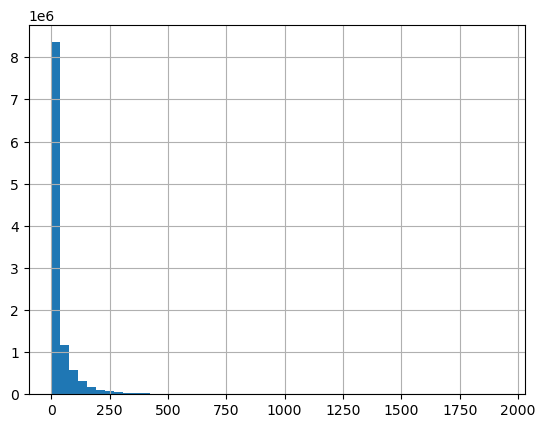

In [73]:
df_val['Validaciones'].hist(bins=50)

Tem uma forte assimetria à direita. Para visualizar melhor a distribuição, vamos considerar só valores menores a 250 e tirar os zeros:

<Axes: >

<Axes: >

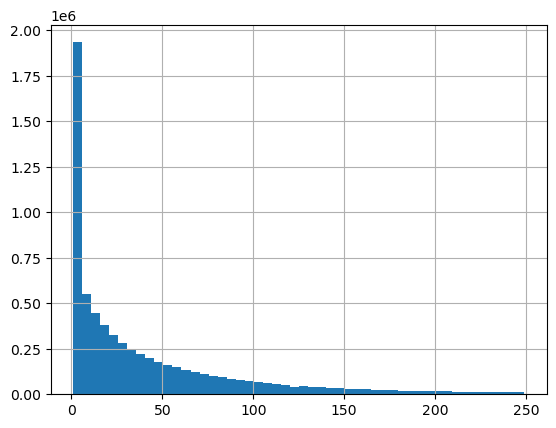

In [74]:
df_val[(df_val['Validaciones'] < 250) & (df_val['Validaciones'] != 0)]['Validaciones'].hist(bins=50)

**CHOOSING THE TRUNK LINE 'ZONA L CARRERA 10'**

Now, I must choose one trunk line ('Línea') for my future plans in this project, so let's check which is the one with the biggest number of validations:

In [75]:
df_val.groupby('Línea')['Validaciones'].agg(['sum', 'mean', 'max']).sort_values(by='sum', ascending=False)

,sum,mean,max
Línea,,,
(30) Zona G NQS Sur,55360447.0,40.845536,1512.0
(34) Zona H Caracas Sur,53448817.0,26.554328,1817.0
(31) Zona F Av. Américas,49356147.0,43.126333,1931.0
(32) Zona C Av. Suba,40728962.0,38.154774,1361.0
(12) Zona L Carrera 10,37844162.0,28.413709,1779.0
(35) Zona D Calle 80,36740121.0,34.963420,1779.0
(38) Zona E NQS Central,30601852.0,34.174487,1106.0
(33) Zona B AutoNorte,29630561.0,49.270208,1124.0
(36) Zona A Caracas,15491935.0,42.739202,1085.0


In [76]:
df_val.groupby('Línea')['Estación'].nunique()

Línea
(11) Zona K Calle 26           9
(12) Zona L Carrera 10        10
(30) Zona G NQS Sur           16
(31) Zona F Av. Américas      10
(32) Zona C Av. Suba          14
(33) Zona B AutoNorte         12
(34) Zona H Caracas Sur       21
(35) Zona D Calle 80          15
(36) Zona A Caracas            6
(37) Zona J Eje Ambiental      2
(38) Zona E NQS Central       11
(39) Zona F Calle 13           6
(40) Zona T Ciudad Bolívar     5
Name: Estación, dtype: int64

The trunk line **Zona L Carrera 10** is fifth in number of entries, and we also have information available from all of its 10 stations (other trunk lines appear to have a lot of stations temporarily closed due to the metro construction). So I will choose to work with this line from this point forward.

In [77]:
# Filter the datasets to only have data from the Zona L Carrera 10 trunk line
df_val10 = df_val[df_val['Línea'].str.contains('Zona L Carrera 10')]
print(df_val10.shape)
df_val10.head(3)

(1331898, 6)


,Fase,Línea,Estación,Acceso de Estación,Fecha,Validaciones
1192,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-04-01 03:45:00,0.0
1193,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-04-01 04:00:00,277.0
1194,Fase 3,(12) Zona L Carrera 10,(10000) Portal 20 de Julio,(01) ALIMENTACIÓN JUAN REY/ALTAMIRA/TIHUAQUE/L...,2025-04-01 04:15:00,257.0


Now, we need to transform the dataset to wide format, so that each station corresponds to one column. We can see that all stations have multiple entrances (Acceso_Estacion), so we need to aggregate all entrances, so we have only one value of the number of entries or exits, for each Date - Estacion combination. 

In [78]:
# Pivot table with aggfunc='sum'
df_wide_val = df_val10.pivot_table(index='Fecha', columns='Estación', values='Validaciones', aggfunc='sum').sort_index()

In [79]:
# Check how many rows we have left
print(df_wide_val.shape)

(30784, 10)


In [80]:
# Check min and max timestamps
print(df_wide_val.index.min())
print(df_wide_val.index.max())

2025-04-01 00:00:00
2026-03-31 23:45:00


In [81]:
# Create missing timestamps. We need 15 min intervals for the whole 24 hours
df_wide_val = df_wide_val.asfreq('15min')

In [82]:
# Check how many rows we have left
print(df_wide_val.shape)
print(df_wide_val.index.nunique())

(35040, 10)
35040


Let's add a column that indicates holidays and another one that indicates the day of the week. These will be used as exogenous variables.

In [83]:
import holidays

co_holidays = holidays.Colombia()

# Column with True or False for holidays
df_wide_val['Feriado'] = [date in co_holidays for date in df_wide_val.index.date]

# Column with 1 and 0 for holidays
df_wide_val['Feriado'] = df_wide_val['Feriado'].astype(int)

# Column with day of the week: monday=0 to sunday=6
df_wide_val['Dia_semana'] = df_wide_val.index.weekday

# Just to check for correctness, let's verify that the only holidays in october and november of 2025 are 13/oct, 3/nov and 17/nov
print(set(df_wide_val[df_wide_val.Feriado == 1].index.date))

df_wide_val['Feriado'] = df_wide_val['Feriado'].astype(int)
df_wide_val.head(3)

{datetime.date(2025, 7, 20), datetime.date(2025, 12, 8), datetime.date(2026, 1, 1), datetime.date(2025, 11, 17), datetime.date(2026, 3, 23), datetime.date(2025, 6, 2), datetime.date(2025, 12, 25), datetime.date(2025, 6, 30), datetime.date(2025, 6, 23), datetime.date(2025, 8, 18), datetime.date(2025, 5, 1), datetime.date(2025, 8, 7), datetime.date(2026, 1, 12), datetime.date(2025, 11, 3), datetime.date(2025, 4, 18), datetime.date(2025, 4, 17), datetime.date(2025, 10, 13)}


Estación,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego,(10010) San Bernardo,Feriado,Dia_semana
Fecha,,,,,,,,,,,,
2025-04-01 00:00:00,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2025-04-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2025-04-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,1


 Create the binary column 'Operativo', with 0 indicating the system is out of the operating hours and 1 indicating the system is operational. The stations are usually open a little before and a little after the operational hours of the routes, so let's generalize the operating window going from 3:45 am to 11:45 pm for entries. During this operating window there can not be any NaN values, but I will keep the NaNs out of the hours of operation.

In [84]:
import datetime

hora_min = datetime.time(3, 45, 0)
hora_max = datetime.time(23, 45, 0)

df_wide_val['Operativo'] = [1 if t >= hora_min and t <= hora_max else 0 for t in df_wide_val.index.time]

In [85]:
# For the entries dataframe: Fill all NaNs between 3:45:00 and 23:30:00. In the out of service hours, I will keep the NaN values.
df_nan = df_wide_val[df_wide_val['Operativo']==1]
print(set(df_nan[(df_nan.isna().any(axis=1))].index.time))
df_nan.isna().sum()

{datetime.time(23, 0), datetime.time(23, 30), datetime.time(3, 45), datetime.time(23, 45), datetime.time(23, 15)}


{datetime.time(23, 0), datetime.time(23, 30), datetime.time(3, 45), datetime.time(23, 45), datetime.time(23, 15)}


Estación
(10000) Portal 20 de Julio              122
(10001) Country Sur                     151
(10002) Av. Primero de Mayo               0
(10003) Ciudad Jardín                   514
(10004) Policarpa                      1220
(10005) Bicentenario                    274
(10006) SAN VICTORINO - NEOS CENTRO     854
(10007) Las Nieves                      826
(10008) San Diego                       937
(10010) San Bernardo                     60
Feriado                                   0
Dia_semana                                0
Operativo                                 0
dtype: int64

In [86]:
df_wide_val.columns

Index(['(10000) Portal 20 de Julio', '(10001) Country Sur',
       '(10002) Av. Primero de Mayo', '(10003) Ciudad Jardín',
       '(10004) Policarpa', '(10005) Bicentenario',
       '(10006) SAN VICTORINO - NEOS CENTRO', '(10007) Las Nieves',
       '(10008) San Diego', '(10010) San Bernardo', 'Feriado', 'Dia_semana',
       'Operativo'],
      dtype='object', name='Estación')

In [96]:
# Boolean mask to fill nan's only during the operational window
mask = (df_wide_val.index.time >= hora_min) & (df_wide_val.index.time <= hora_max)
df_wide_val.loc[mask] = df_wide_val.fillna(0.0)

# Change any number in the out of service window to a null NaN value
mask1 = (df_wide_val.index.time < hora_min) | (df_wide_val.index.time > hora_max)
df_wide_val.loc[mask1] = np.nan

# Change the order of the columns in the dataframe so the stations are in geographical order
new_order = ['(10000) Portal 20 de Julio', '(10001) Country Sur',
              '(10002) Av. Primero de Mayo', '(10003) Ciudad Jardín',
              '(10004) Policarpa', '(10010) San Bernardo', '(10005) Bicentenario',
              '(10006) SAN VICTORINO - NEOS CENTRO', '(10007) Las Nieves',
              '(10008) San Diego', 'Feriado', 'Dia_semana',
              'Operativo']
df_wide_val = df_wide_val.reindex(columns=new_order)

# Save new dataframe to a csv file
df_wide_val.to_csv('../data/validaciones12m.csv', index=True, encoding='utf-8')

**PLOTTING THE TIME SERIES**

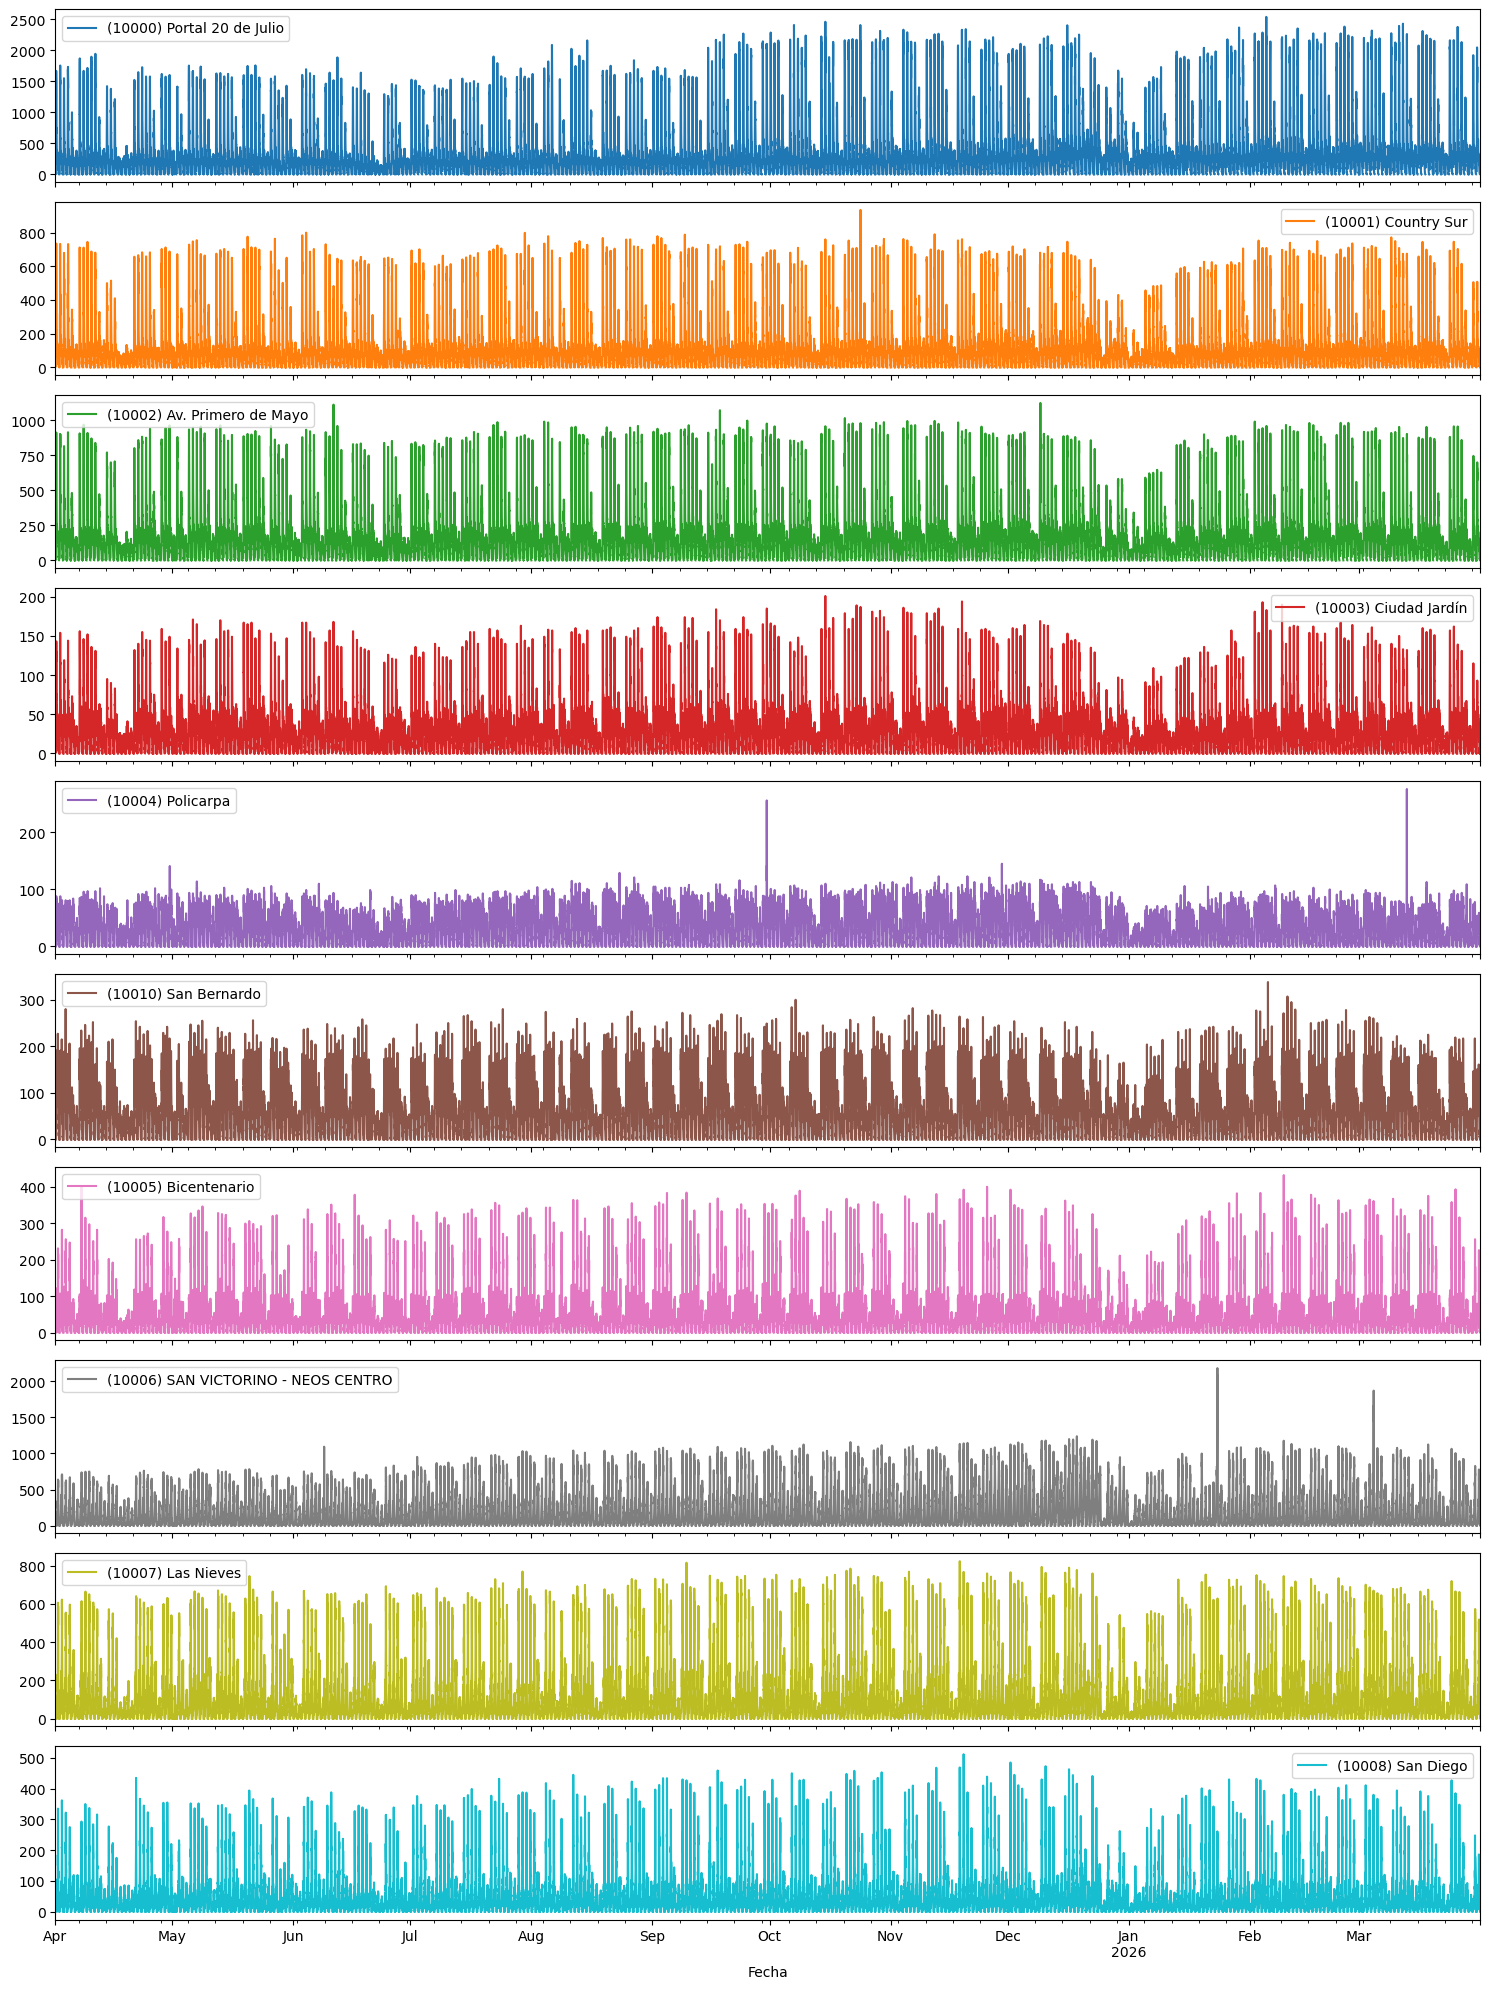

In [88]:
# Entries (validations) per station in the trunk line Carrera 10
df_wide_val.iloc[:, 0:10].plot(subplots=True, figsize=(15, 20), layout=(10, 1))
plt.tight_layout()
plt.show()

There is an evident and expected drop in the number of validations during holy week (third week of april), and at the end of december and the beginning of january in all stations. Now let's see only the last two months:

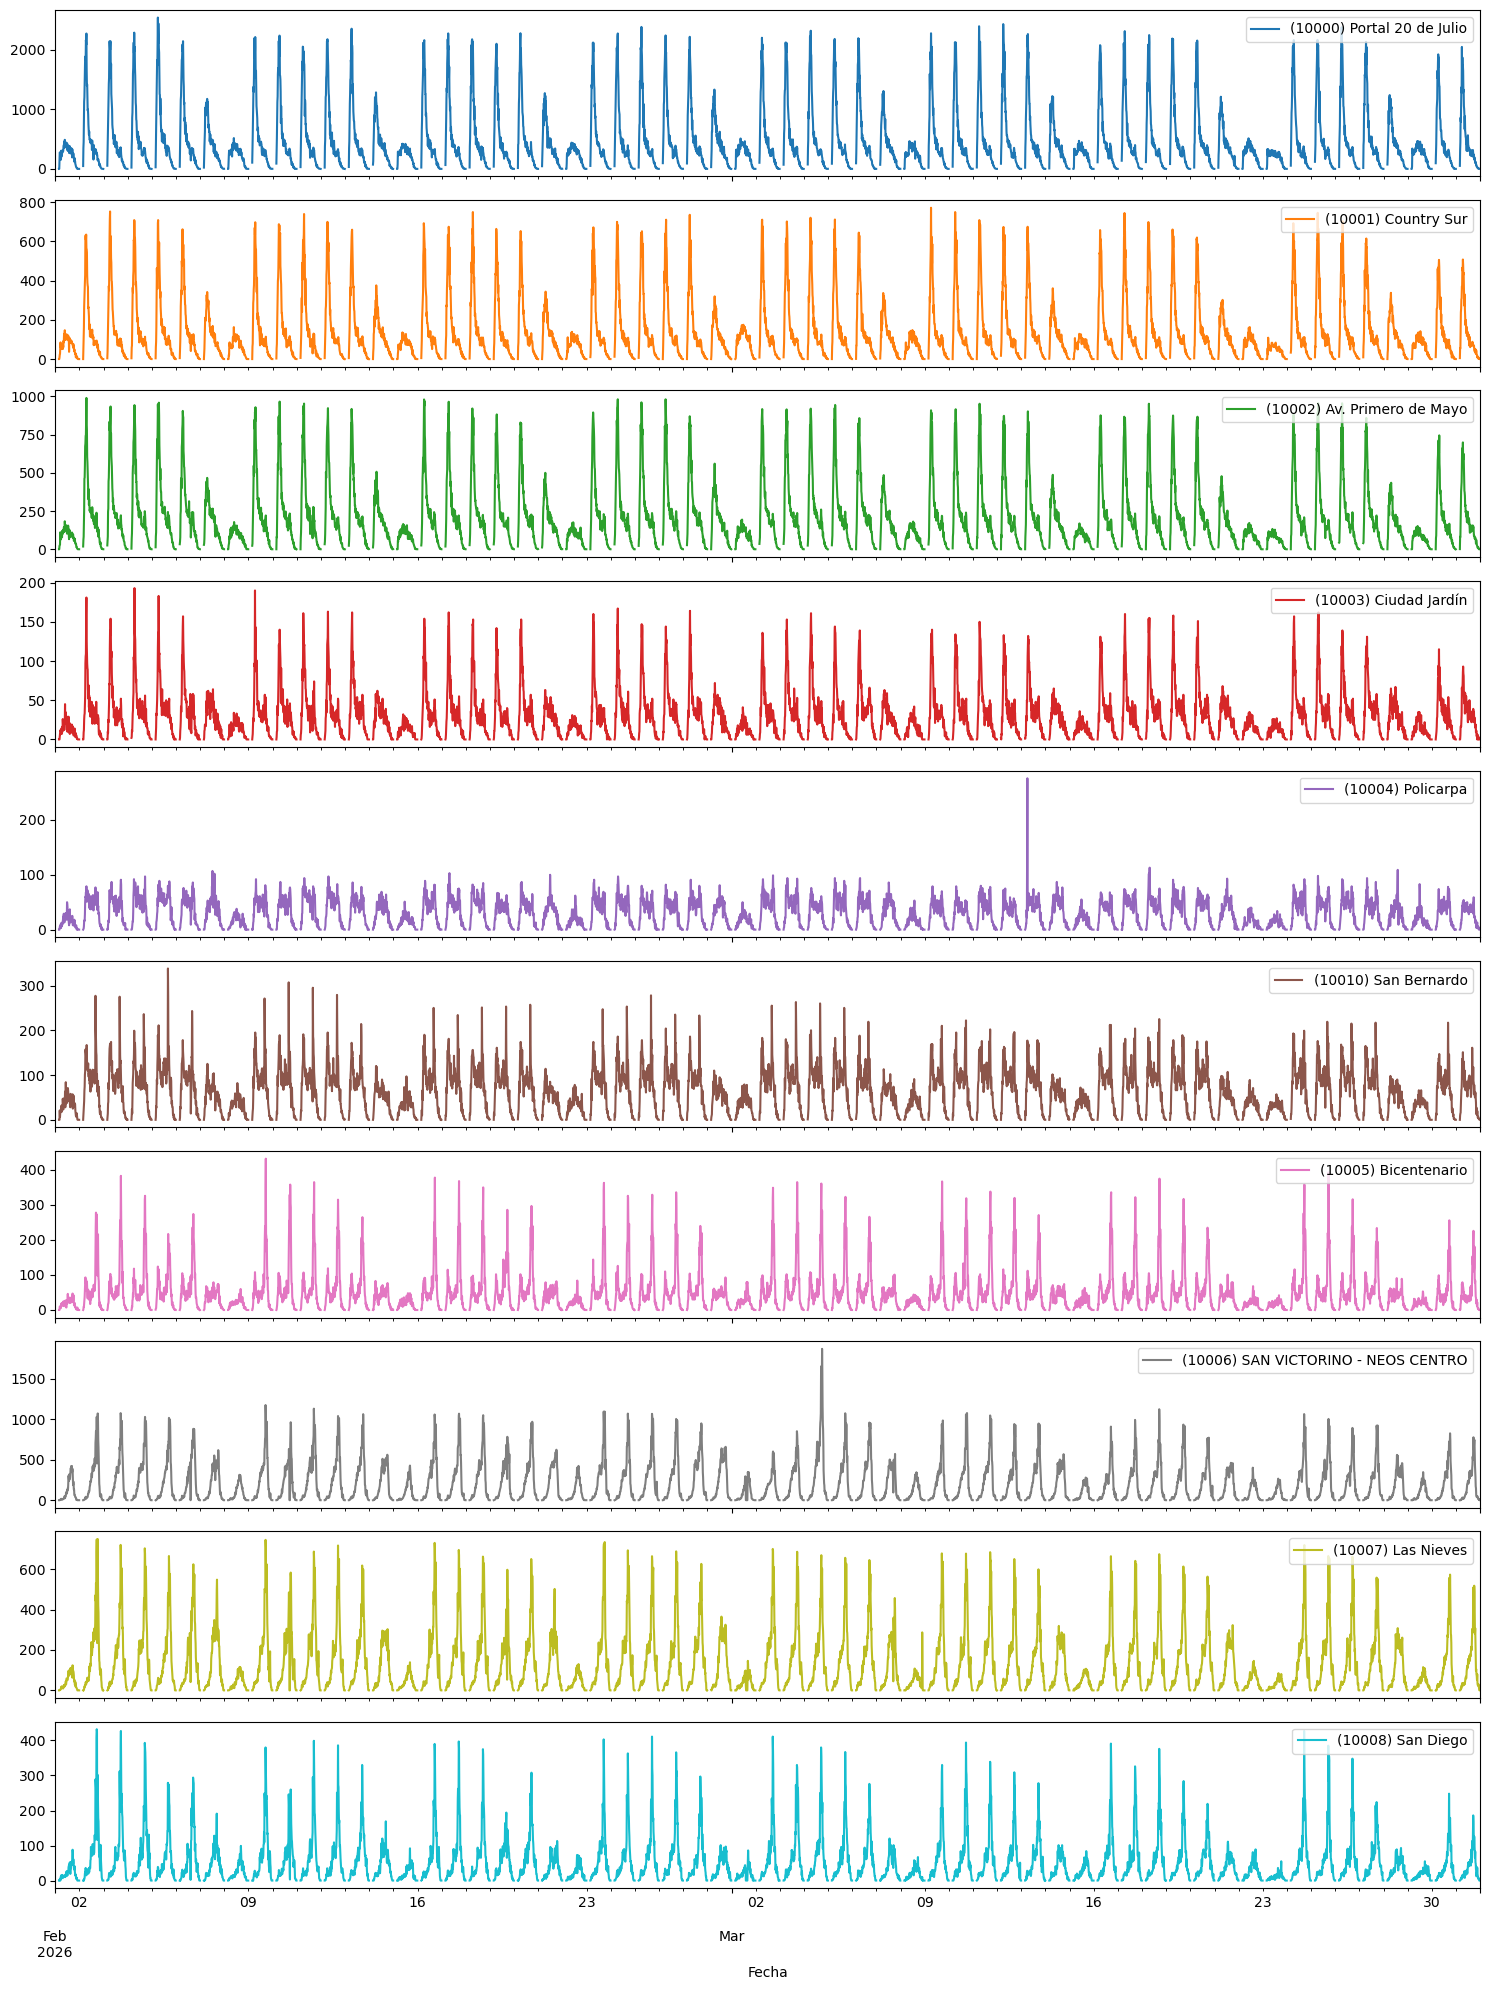

In [92]:
# Entries (validations) per station in the trunk line Carrera 10
df_wide_val.loc['2026-02-01':'2026-03-31'].iloc[:, 0:10].plot(subplots=True, figsize=(15, 20), layout=(10, 1))
plt.tight_layout()
plt.show()

The graphs are ordered according to the geographical location of the stations and it's interesting that we can see a pattern in the spikes: In the Portal 20 de Julio and the subsequent stations, we can see spikes going up fast very early every morning, and going down in a more controled way throughout the day. The stations that are in the middle of the trunk show a bimodal pattern, and the last stations show again a notorious spike but towards the end of the day. This corresponds to the fact that the Portal and the first stations are located in areas of the city that are mostly residential, while the last ones are located towards/in the city center, where a lot of people have their workplaces. So, spikes in the morning are due to people leaving for work, and spikes in the evening are due to people going back to their homes from the city center.

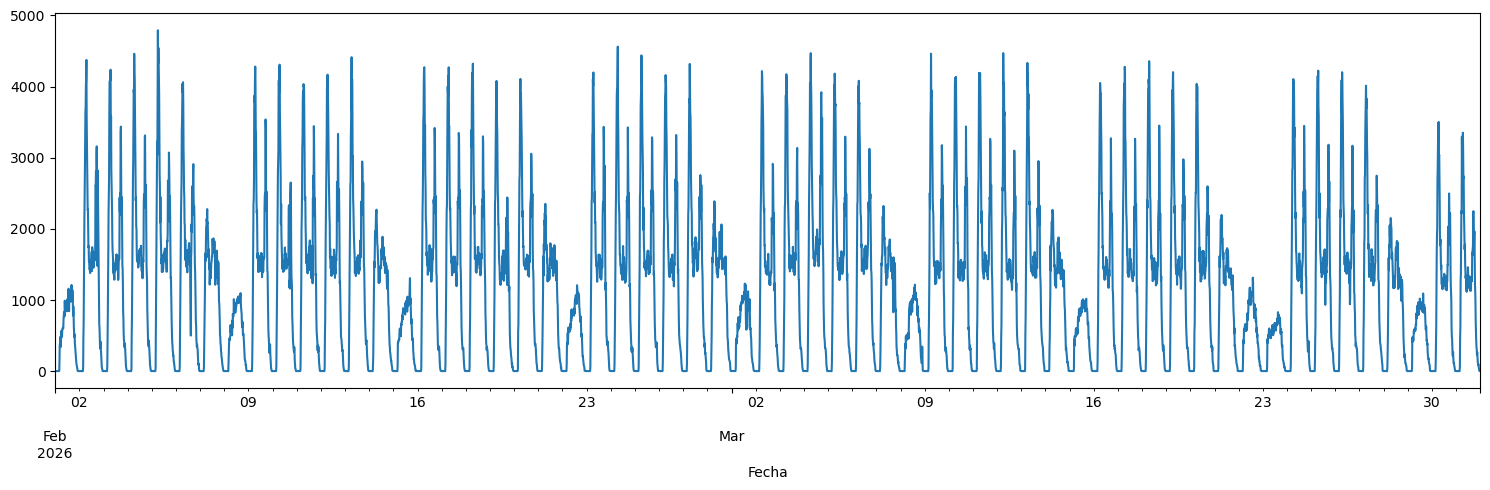

In [ ]:
# Global time series for the trunk line 'Carrera 10', last two months
df_wide_val['Total Validaciones'] = df_wide_val.iloc[:, 0:10].sum(axis=1)
df_total = df_wide_val['Total Validaciones'].loc['2026-02-01':'2026-03-31']
df_total.plot(subplots=True, figsize=(15, 5))
plt.tight_layout()
plt.show()


We can clearly see that the number of validations (and therefore users) in the system decreases significantly in the weekends and holidays (for example march the 23d was a holiday monday)